In [44]:
import pandas as pd 
import numpy as np

# DATA PREPROCESSING

In [45]:
people = pd.read_csv("01_people.csv")
abilities = pd.read_csv("02_abilities.csv")
education = pd.read_csv("03_education.csv")
experience = pd.read_csv("04_experience.csv")  
person_skills = pd.read_csv("05_person_skills.csv")
skills = pd.read_csv("06_skills.csv")
job_descriptions = pd.read_csv("job_descriptions.csv")


In [46]:
print(people.shape)
print(abilities.shape)
print(education.shape)
print(experience.shape)
print(person_skills.shape)
print(skills.shape)

(54933, 5)
(1219473, 2)
(75999, 5)
(265404, 6)
(2483376, 2)
(226760, 1)


In [47]:
people.head()

,person_id,name,email,phone,linkedin
0,1,Database Administrator,NaN,NaN,NaN
1,2,Database Administrator,NaN,NaN,NaN
2,3,Oracle Database Administrator,NaN,NaN,NaN
3,4,Amazon Redshift Administrator and ETL Develope...,NaN,NaN,NaN
4,5,Scrum Master Scrum Master Scrum Master,NaN,NaN,NaN


In [48]:
print("People:")
print(people.columns)

print("\nAbilities:")
print(abilities.columns)

print("\nEducation:")
print(education.columns)

print("\nExperience:")
print(experience.columns)

print("\nPerson Skills:")
print(person_skills.columns)

print("\nSkills:")
print(skills.columns)

People:
Index(['person_id', 'name', 'email', 'phone', 'linkedin'], dtype='str')

Abilities:
Index(['person_id', 'ability'], dtype='str')

Education:
Index(['person_id', 'institution', 'program', 'start_date', 'location'], dtype='str')

Experience:
Index(['person_id', 'title', 'firm', 'start_date', 'end_date', 'location'], dtype='str')

Person Skills:
Index(['person_id', 'skill'], dtype='str')

Skills:
Index(['skill'], dtype='str')


In [49]:
education_text = (
    education.groupby("person_id")
    .agg({
        "institution": lambda x: " | ".join(
            x.dropna().astype(str)
        ),
        "program": lambda x: " | ".join(
            x.dropna().astype(str)
        )
    })
    .reset_index()
)

In [55]:
experience_text = (
    experience.groupby("person_id")
    .agg({
        "title": lambda x: " | ".join(
            x.dropna().astype(str)
        ),
        "firm": lambda x: " | ".join(
            x.dropna().astype(str)
        )
    })
    .reset_index()
)
    


In [56]:
skills_text = (
    person_skills.groupby("person_id")["skill"]
    .apply(lambda x: ", ".join(
        x.dropna().astype(str)
    ))
    .reset_index()
)

skills_text.rename(
    columns={"skill": "skills"},
    inplace=True
)

In [57]:
abilities_text = (
    abilities.groupby("person_id")["ability"]
    .apply(lambda x: ", ".join(
        x.dropna().astype(str)
    ))
    .reset_index()
)

abilities_text.rename(
    columns={"ability": "abilities"},
    inplace=True
)

In [58]:
resume_df = people.copy()

resume_df = resume_df.merge(
    education_text,
    on="person_id",
    how="left"
)

resume_df = resume_df.merge(
    experience_text,
    on="person_id",
    how="left"
)

resume_df = resume_df.merge(
    skills_text,
    on="person_id",
    how="left"
)
resume_df = resume_df.merge(
    abilities_text,
    on="person_id",
    how="left"
)

In [78]:
resume_df["resume_text"] = (
    resume_df["institution"].fillna("") + " " +
    resume_df["program"].fillna("") + " " +
    resume_df["title"].fillna("") + " " +
    resume_df["firm"].fillna("") + " " +
    resume_df["skills"].fillna("") + " " +
    resume_df["abilities"].fillna("")
)

In [79]:
resume_df.to_csv(
    "Resume_dataset.csv",
    index=False
)

In [80]:
resume_df.head()

,person_id,name,email,phone,linkedin,institution,program,title,firm,skills,abilities,resume_text
0,1,Database Administrator,NaN,NaN,NaN,Lead City University,Bachelor of Science,Database Administrator | Database Administrator,Family Private Care LLC | Incomm,"Database administration, Database, Ms sql serv...","Installation and Building Server, Running Back...",Lead City University Bachelor of Science Datab...
1,2,Database Administrator,NaN,NaN,NaN,lagos state university,bsc in computer science,Database Administrator,Intercontinental Registry,"sql server management studio, visual studio, s...","database management systems administration, de...",lagos state university bsc in computer science...
2,3,Oracle Database Administrator,NaN,NaN,NaN,"JNTU - Kakinada, Andhra Pradesh",Master of Computer Applications in Science and...,Oracle Database Administrator | Oracle Databas...,Cognizant | Convergys,"DATABASES, ORACLE (4 years), ORACLE 10G, SQL, ...","Over 4+ years of Experience as Architecture, E...","JNTU - Kakinada, Andhra Pradesh Master of Comp..."
3,4,Amazon Redshift Administrator and ETL Develope...,NaN,NaN,NaN,University of Informatics,Bachelor in Computer Science,Amazon Redshift Administrator and ETL Develope...,"MSP Recovery - Fort Lauderdale, FL | CEAACES -...",Maintain multiple database environments (Redsh...,"SQL management, PostgresSQL, Oracle, MySQL, mi...",University of Informatics Bachelor in Computer...
4,5,Scrum Master Scrum Master Scrum Master,NaN,NaN,NaN,Virginia Commomwealth University,,Scrum Master | Oracle Database Administrator/ ...,Quest Technologies | Prudential | Time Warner ...,"Scrum, Agile software development, Product bac...","Scrum Master, Agile software development, Prod...",Virginia Commomwealth University Scrum Master...


In [81]:
import re
resume_df = resume_df.fillna("")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()
    
for col in resume_df.columns:
    resume_df[col] = resume_df[col].map(clean_text)
    
resume_df = resume_df.drop_duplicates()

In [140]:
np.random.seed(42)

indices = np.random.choice(
    resume_df.index,
    size=5000,
    replace=False
)
sample_5000 = resume_df.loc[indices]

sample_5000.to_csv(
    "sample_resumes.csv",
    index=False
)
sample_5000.head()

,person_id,name,email,phone,linkedin,institution,program,title,firm,skills,abilities,resume_text
19959,19960,oracle database administrator architect oracle...,,,,bharathiyar university aspen university,bachelor of computer science mba in project ma...,oracle database administrator architect lead o...,fannie mae john deere company elm resources ag...,oracle 11g 10g 9i 8i database administration d...,oracle database administration database archit...,bharathiyar university aspen university bachel...
11489,11490,cyber surety journeyman,,,https www linkedin com in thughes86,american military university western governors...,bachelors of science in information systems se...,cyber surety journeyman cyber security analyst...,usaf bylight it professionals bylight it profe...,vulnerability management nessus security cente...,cyber security system administration customer ...,american military university western governors...
18741,18742,scott township,,,,luzerne county community college wilkes univer...,computer programming certificate bachelor of s...,computer systems analyst programmer database s...,united states postal service jenkins township ...,oracle databases pl sql database design data a...,database design pl sql performance tuning data...,luzerne county community college wilkes univer...
51687,51688,michael owuor,,,https www linkedin com in michaelowuor,keller graduate school of management moi unive...,master of business administration in network a...,service desk manager service desk lead technic...,highpoint solutions llc highpoint solutions ll...,active directory windows server administration...,active directory and windows server administra...,keller graduate school of management moi unive...
3270,3271,sylvia castro,,,https www linkedin com in sylviacastro3,devry university,bachelor of science in computer information sy...,front end developer intern web lms programmer ...,americaneagle com cambridge business publisher...,html asp net moodle html css customer service ...,front end developer web development project ma...,devry university bachelor of science in comput...


# EMBEDDING

In [141]:
!pip install sentence_transformers 

In [142]:
from sentence_transformers import SentenceTransformer

In [143]:
model = SentenceTransformer("all-MiniLM-L6-v2")
resume_embeddings = model.encode(sample_5000["resume_text"].tolist())
resume_embeddings[0:100]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

array([[-0.04771717, -0.03146868, -0.08155416, ..., -0.07232824,
        -0.00619856,  0.019402  ],
       [ 0.01888157, -0.04861255, -0.04308324, ..., -0.03730334,
        -0.08635137,  0.02322121],
       [ 0.02967682, -0.02948564,  0.03544934, ..., -0.03531994,
        -0.02498289,  0.00079983],
       ...,
       [-0.05359964, -0.07212778, -0.00700709, ..., -0.0531946 ,
         0.05450255,  0.00909372],
       [-0.04271669, -0.06319634, -0.00116442, ...,  0.0165311 ,
         0.02099096, -0.01076625],
       [-0.02506168, -0.05381679, -0.02481456, ..., -0.07015868,
        -0.03781448,  0.01005055]], shape=(100, 384), dtype=float32)

In [144]:
import numpy as np
np.save("resume_embeddings.npy",resume_embeddings)

In [145]:
np.load("resume_embeddings.npy")

array([[-0.04771717, -0.03146868, -0.08155416, ..., -0.07232824,
        -0.00619856,  0.019402  ],
       [ 0.01888157, -0.04861255, -0.04308324, ..., -0.03730334,
        -0.08635137,  0.02322121],
       [ 0.02967682, -0.02948564,  0.03544934, ..., -0.03531994,
        -0.02498289,  0.00079983],
       ...,
       [ 0.03291575, -0.04180297, -0.02039681, ..., -0.01325606,
        -0.01545533,  0.04872361],
       [-0.08951943, -0.09978774, -0.02947871, ...,  0.06948517,
         0.08931544, -0.04364599],
       [-0.08910073, -0.05936279, -0.02143597, ..., -0.03112161,
        -0.01992007, -0.04305681]], shape=(5000, 384), dtype=float32)

In [146]:
resume_df.to_csv("clean_resume_data.csv",index=False)

In [147]:
!pip install chromadb

In [148]:
import chromadb

In [150]:
resume_database = chromadb.PersistentClient(path="resume_database")
resume_collection = resume_database.get_or_create_collection(name="resume_collection")

resume_ids = []
for i in range(len(sample_5000)):
    resume_ids.append(str(i))

resume_collection.add(ids=resume_ids, documents=sample_5000["resume_text"].tolist(), embeddings=resume_embeddings.tolist())


In [151]:
resume_collection.count()

5000

In [152]:
jd_df = pd.read_csv("job_descriptions.csv")
jd_df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [153]:
jd_df = jd_df[
    [
        "Job Id",
        "Job Title",
        "Role",
        "Experience",
        "Qualifications",
        "skills",
        "Responsibilities",
        "Job Description",
    ]
]

In [170]:
sample_jds = (
    jd_df
    .sample(n=10, random_state=42)
    .reset_index(drop=True)
)

In [199]:
from sentence_transformers import SentenceTransformer

# Load the embedding model once
model = SentenceTransformer("all-MiniLM-L6-v2")

for i, jd in sample_jds.iterrows():

    jd_text = f"""
Job Title: {jd['Job Title']}

Role: {jd['Role']}

Experience: {jd['Experience']}

Qualifications:
{jd['Qualifications']}

Skills:
{jd['skills']}

Responsibilities:
{jd['Responsibilities']}

Job Description:
{jd['Job Description']}
"""
    jd_embedding = model.encode(jd_text)

    results = resume_collection.query(
        query_embeddings=[jd_embedding.tolist()],
        n_results=3
    )

    top_resumes = results["documents"][0]
    top_ids = results["ids"][0]

    print(f"JD {i+1}:")
    print(top_ids)
    


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

JD 1:
['1320', '1053', '4180']
JD 2:
['3766', '931', '2590']
JD 3:
['4125', '4578', '1531']
JD 4:
['2439', '3147', '4899']
JD 5:
['4125', '4578', '1531']
JD 6:
['4869', '4419', '4848']
JD 7:
['2590', '2969', '518']
JD 8:
['2511', '1531', '2573']
JD 9:
['4869', '245', '113']
JD 10:
['113', '1320', '4869']


In [187]:
!pip install python-dotenv

In [193]:
from getpass import getpass

api_key = getpass("Enter your Groq API Key: ")

with open(".env", "w") as f:
    f.write(f"GROQ_API_KEY={api_key}")

Enter your Groq API Key:  ········


In [194]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)

api_key = os.getenv("GROQ_API_KEY")

print(api_key[:10])


gsk_FtV1Wk


In [195]:
from openai import OpenAI
from dotenv import load_dotenv
import os
import pandas as pd
import re

In [201]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

model = SentenceTransformer("all-MiniLM-L6-v2")

results = []

system_prompt = """
You are an experienced recruiter.

Your task is to evaluate candidate resumes against a given job description.

Rules:
- Be objective and unbiased.
- Use only the information provided in the resume and job description.
- Do not assume missing qualifications.
- Evaluate each category independently.
- Return ONLY the requested format.
- Do NOT calculate the final score.
"""

weights = {
    "skills": 0.35,
    "experience": 0.25,
    "education": 0.10,
    "domain": 0.15,
    "keyword": 0.10,
    "resume_quality": 0.05
}

for i, jd in sample_jds.iterrows():

    jd_text = f"""
Job Title: {jd['Job Title']}

Role: {jd['Role']}

Experience: {jd['Experience']}

Qualifications:
{jd['Qualifications']}

Skills:
{jd['skills']}

Responsibilities:
{jd['Responsibilities']}

Job Description:
{jd['Job Description']}
"""

    jd_embedding = model.encode(jd_text)

    query_results = resume_collection.query(
        query_embeddings=[jd_embedding.tolist()],
        n_results=3
    )

    top_resumes = query_results["documents"][0]
    top_ids = query_results["ids"][0]

    for resume_id, resume_text in zip(top_ids, top_resumes):

        user_prompt = f"""
Job Description:
{jd_text}

Candidate Resume:
{resume_text}

Evaluate how well the candidate matches the job description.

Score the following:

1. Skills Match (0-25)
2. Experience Match (0-25)
3. Education Match (0-15)
4. Domain Relevance (0-15)
5. Keyword Match (0-10)
6. Resume Quality (0-10)

Guidelines:
- Give higher scores only when the resume clearly satisfies the job requirements.
- Prioritize required technical skills and relevant experience.
- Do not reward unrelated experience.
- Do not infer qualifications that are not explicitly mentioned.

Return EXACTLY in this format:

Skills Score: <number>
Experience Score: <number>
Education Score: <number>
Domain Score: <number>
Keyword Score: <number>
Resume Quality Score: <number>

Recommendation:
...
"""

        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {
                    "role": "system",
                    "content": system_prompt
                },
                {
                    "role": "user",
                    "content": user_prompt
                }
            ],
            temperature=0
        )

        evaluation = response.choices[0].message.content

        def extract_score(pattern):
            match = re.search(pattern, evaluation)
            return int(match.group(1)) if match else 0

        skills = extract_score(r"Skills Score:\s*(\d+)")
        experience = extract_score(r"Experience Score:\s*(\d+)")
        education = extract_score(r"Education Score:\s*(\d+)")
        domain = extract_score(r"Domain Score:\s*(\d+)")
        keyword = extract_score(r"Keyword Score:\s*(\d+)")
        resume_quality = extract_score(r"Resume Quality Score:\s*(\d+)")

        skills_norm = skills / 25
        experience_norm = experience / 25
        education_norm = education / 15
        domain_norm = domain / 15
        keyword_norm = keyword / 10
        resume_quality_norm = resume_quality / 10

        final_score = (
            skills_norm * weights["skills"] +
            experience_norm * weights["experience"] +
            education_norm * weights["education"] +
            domain_norm * weights["domain"] +
            keyword_norm * weights["keyword"] +
            resume_quality_norm * weights["resume_quality"]
        ) * 100

        final_score = round(final_score, 2)

        recommendation_match = re.search(
            r"Recommendation:\s*(.*)",
            evaluation,
            re.DOTALL
        )

        recommendation = (
            recommendation_match.group(1).strip()
            if recommendation_match
            else "Not Available"
        )

        results.append({
            "Job ID": jd["Job Id"],
            "Job Title": jd["Job Title"],
            "Resume ID": resume_id,
            "Skills": skills,
            "Experience": experience,
            "Education": education,
            "Domain": domain,
            "Keyword": keyword,
            "Resume Quality": resume_quality,
            "Final Score": final_score,
            "Recommendation": recommendation,
            "Evaluation": evaluation
        })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["Job ID", "Final Score"],
    ascending=[True, False]
)

results_df = (
    results_df
    .groupby("Job ID", group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

results_df["Rank"] = (
    results_df
    .groupby("Job ID")
    .cumcount() + 1
)

results_df = results_df[
    [
        "Job ID",
        "Job Title",
        "Rank",
        "Resume ID",
        "Skills",
        "Experience",
        "Education",
        "Domain",
        "Keyword",
        "Resume Quality",
        "Final Score",
        "Recommendation",
        "Evaluation"
    ]
]

display(results_df)

results_df.to_csv("ats_report.csv", index=False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,Job ID,Job Title,Rank,Resume ID,Skills,Experience,Education,Domain,Keyword,Resume Quality,Final Score,Recommendation,Evaluation
0,687428170224095,Account Manager,1,245,20,20,0,10,5,8,67.00,The candidate has a strong background in proje...,Skills Score: 20\nExperience Score: 20\nEducat...
1,687428170224095,Account Manager,2,4869,10,5,0,5,5,8,33.00,The candidate has some relevant skills such as...,Skills Score: 10\nExperience Score: 5\nEducati...
2,687428170224095,Account Manager,3,113,0,0,0,0,0,8,4.00,The candidate has a strong resume with a clear...,Skills Score: 0\nExperience Score: 0\nEducatio...
3,1017340707950150,Procurement Manager,1,1053,20,15,0,10,5,8,62.00,The candidate has relevant experience in procu...,Skills Score: 20\nExperience Score: 15\nEducat...
4,1017340707950150,Procurement Manager,2,1320,15,10,0,10,5,8,50.00,The candidate has relevant skills such as stra...,Skills Score: 15\nExperience Score: 10\nEducat...
5,1017340707950150,Procurement Manager,3,4180,10,0,0,0,0,5,16.50,The candidate's resume does not clearly match ...,Skills Score: 10\nExperience Score: 0\nEducati...
6,1690092345385690,Business Development Manager,1,113,15,5,10,5,5,8,46.67,The candidate has a strong educational backgro...,Skills Score: 15\nExperience Score: 5\nEducati...
7,1690092345385690,Business Development Manager,2,4869,15,5,10,5,5,8,46.67,The candidate has relevant education and some ...,Skills Score: 15\nExperience Score: 5\nEducati...
8,1690092345385690,Business Development Manager,3,1320,10,5,0,5,5,8,33.00,"The candidate has some relevant skills, such a...",Skills Score: 10\nExperience Score: 5\nEducati...
9,1747904829392680,Art Teacher,1,4125,20,15,10,10,5,8,68.67,The candidate has a strong background in art e...,Skills Score: 20\nExperience Score: 15\nEducat...


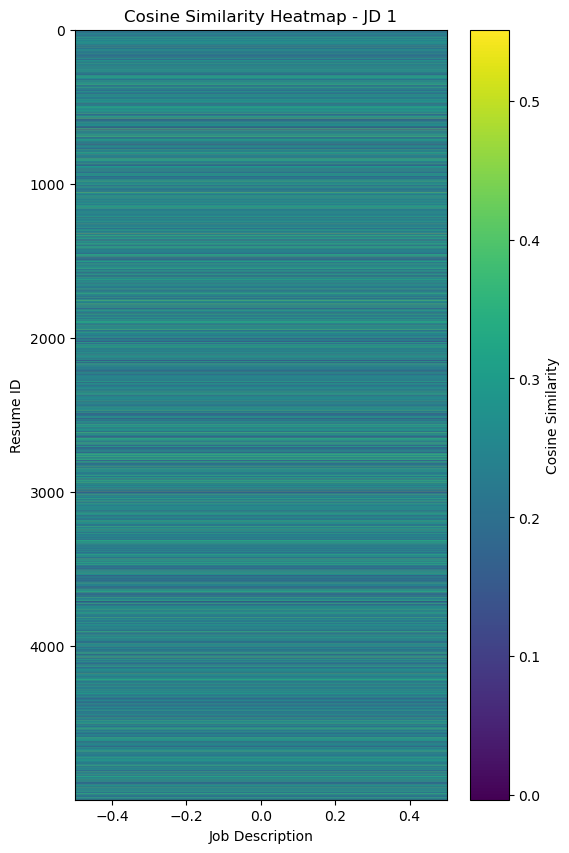

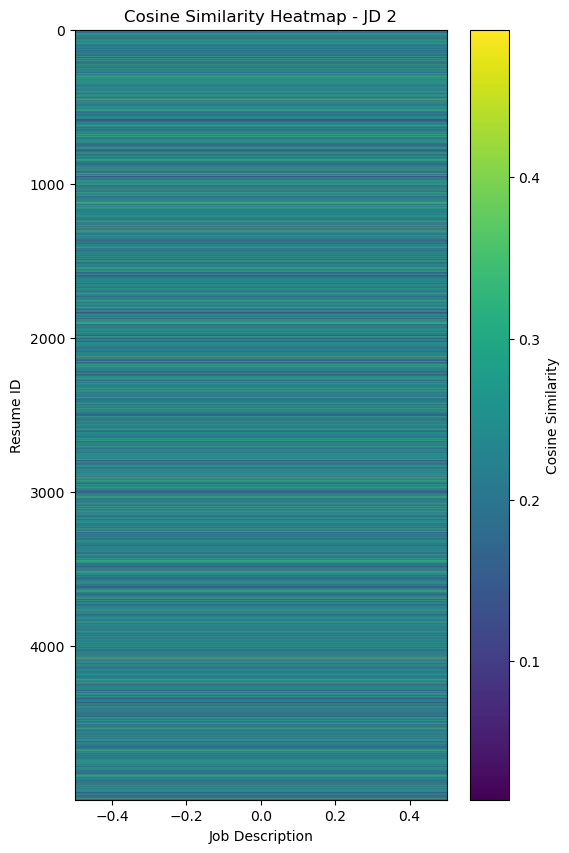

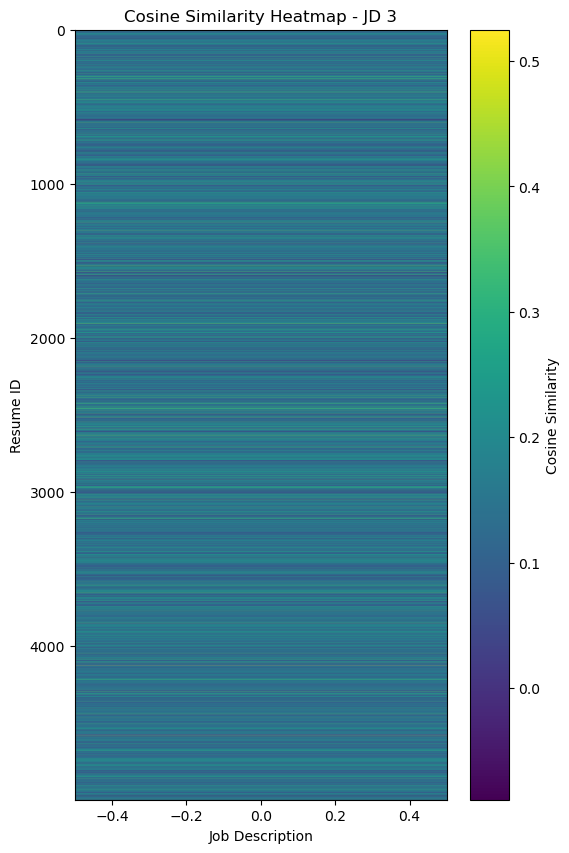

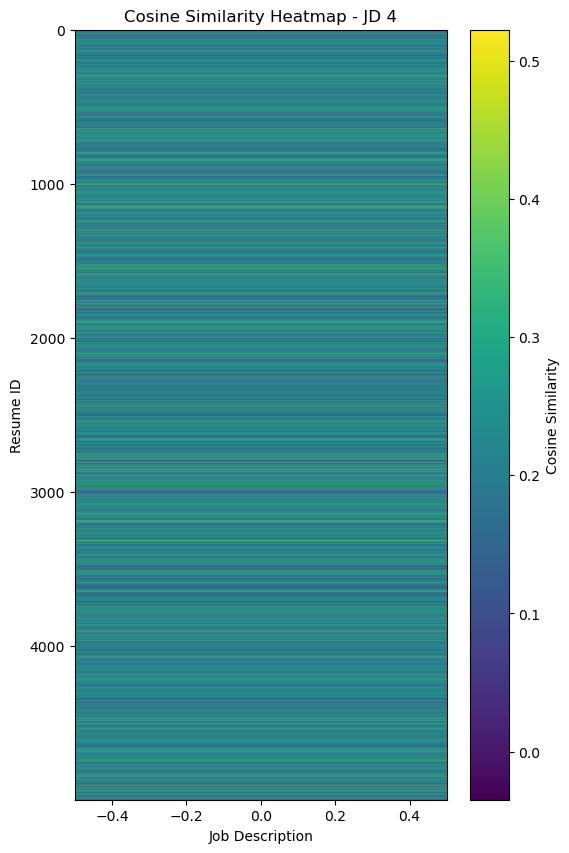

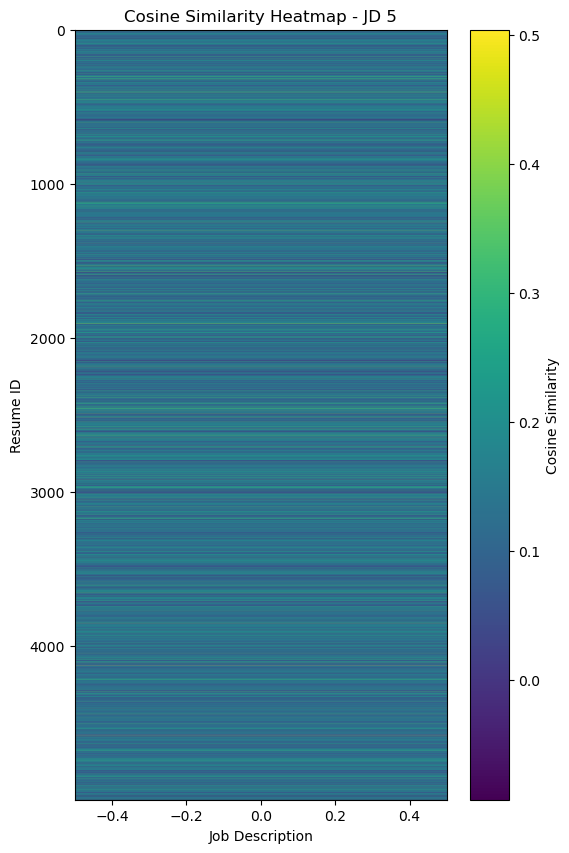

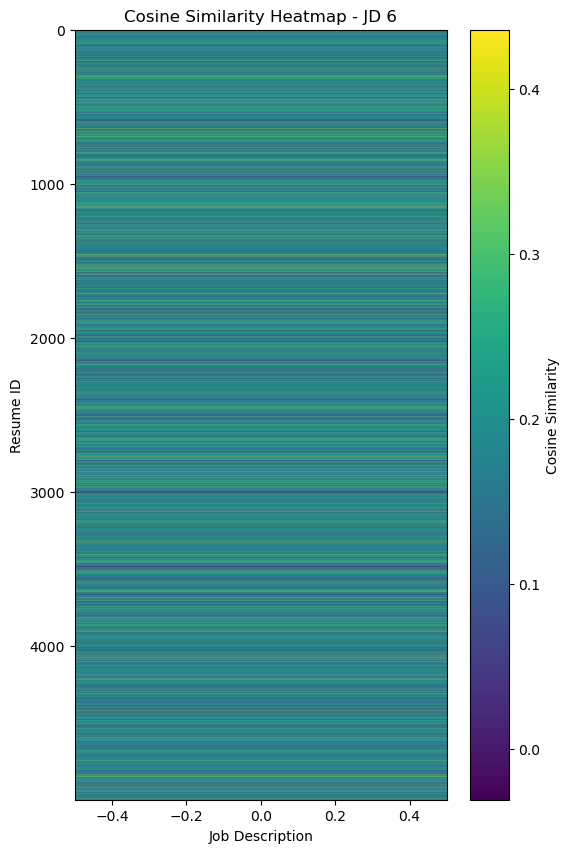

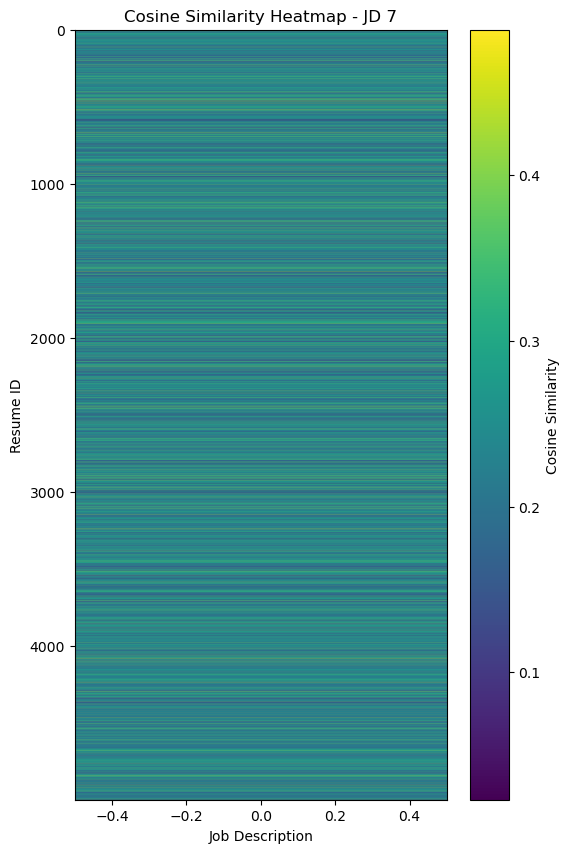

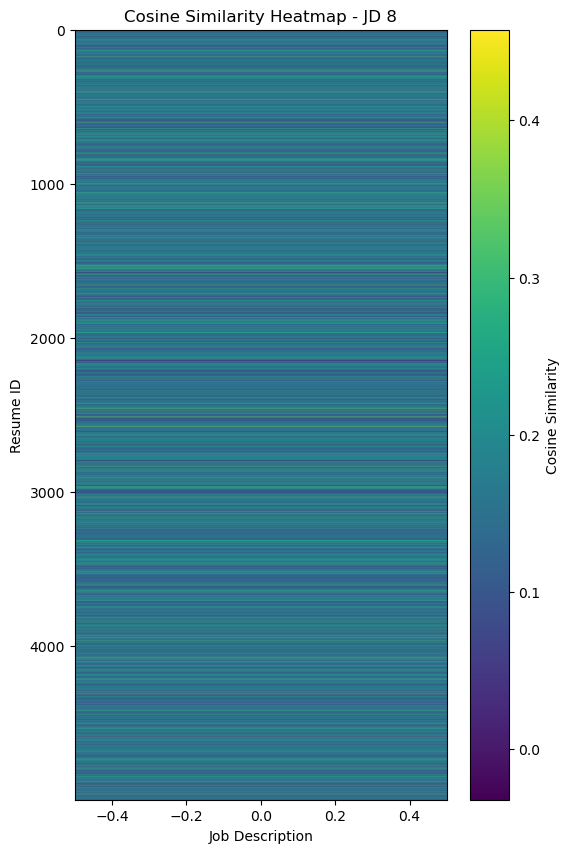

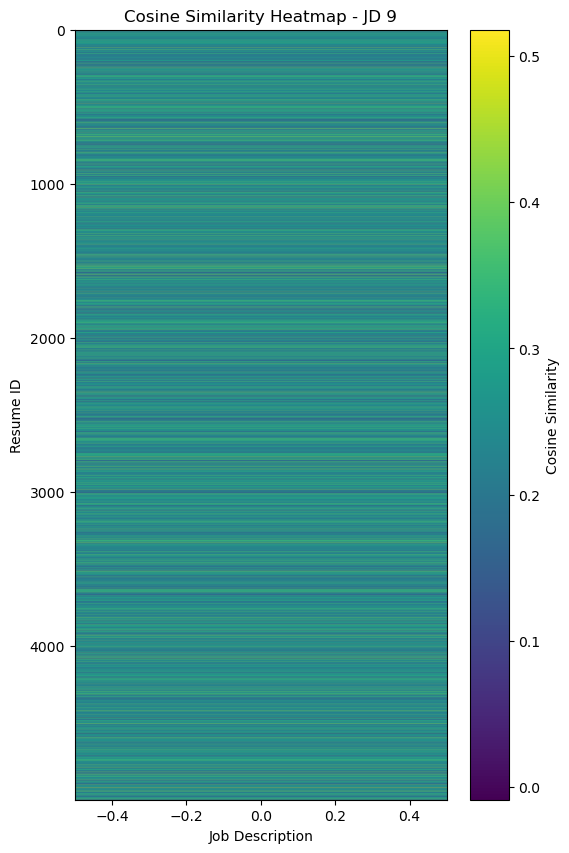

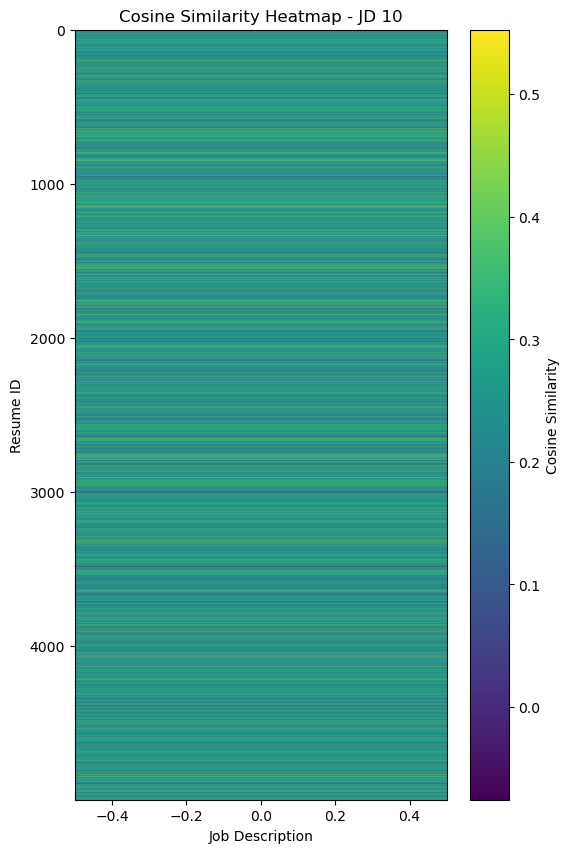

In [197]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

resume_embeddings = np.array(resume_embeddings)

for i, jd in sample_jds.iterrows():

    jd_text = f"""
Job Title: {jd['Job Title']}

Role: {jd['Role']}

Experience: {jd['Experience']}

Qualifications:
{jd['Qualifications']}

Skills:
{jd['skills']}

Responsibilities:
{jd['Responsibilities']}

Job Description:
{jd['Job Description']}
"""

    jd_embedding = model.encode(jd_text)
    jd_embedding = np.array(jd_embedding)

    similarities = cosine_similarity(
        resume_embeddings,
        jd_embedding.reshape(1, -1)
    )

    plt.figure(figsize=(6, 10))

    plt.imshow(similarities, aspect="auto", cmap="viridis")

    plt.colorbar(label="Cosine Similarity")

    plt.xlabel("Job Description")
    plt.ylabel("Resume ID")

    plt.title(f"Cosine Similarity Heatmap - JD {i+1}")

    plt.show()

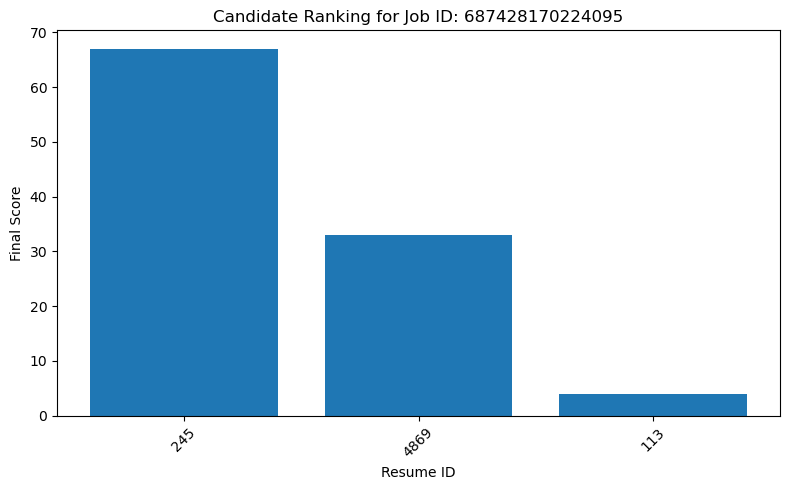

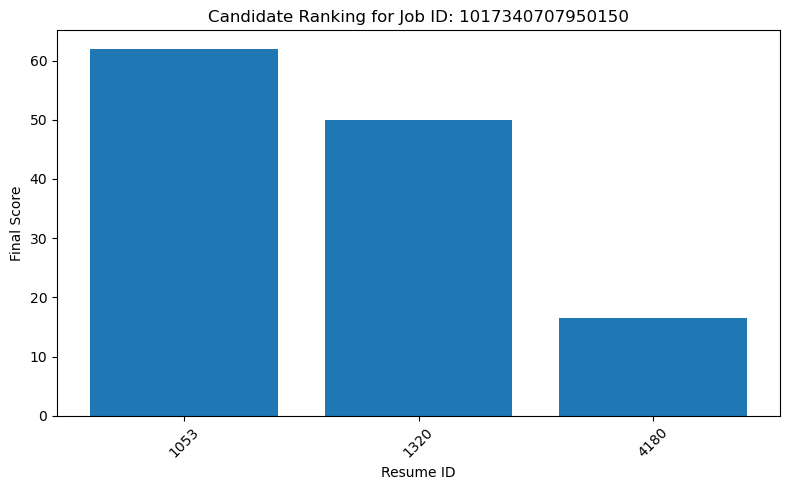

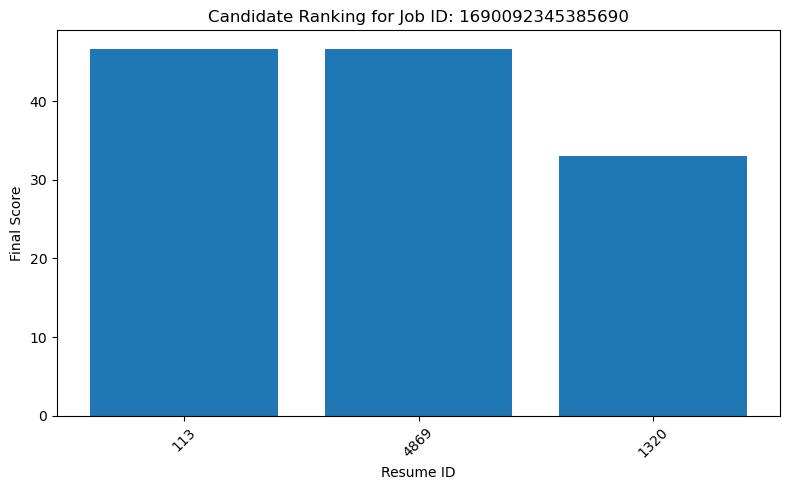

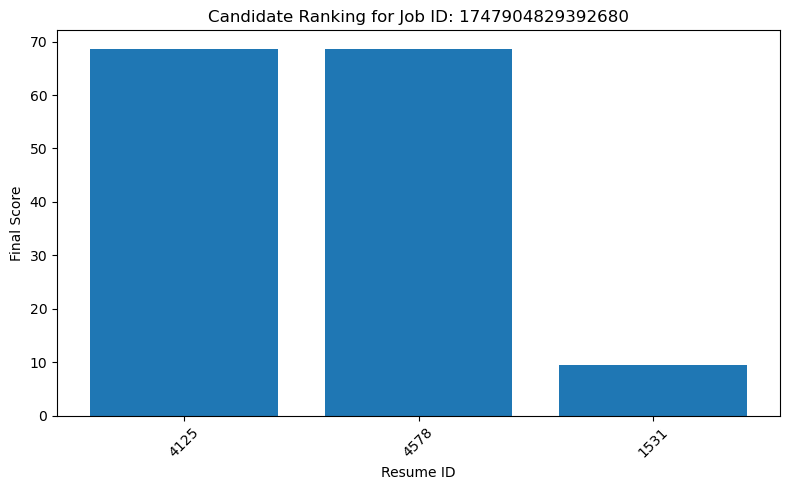

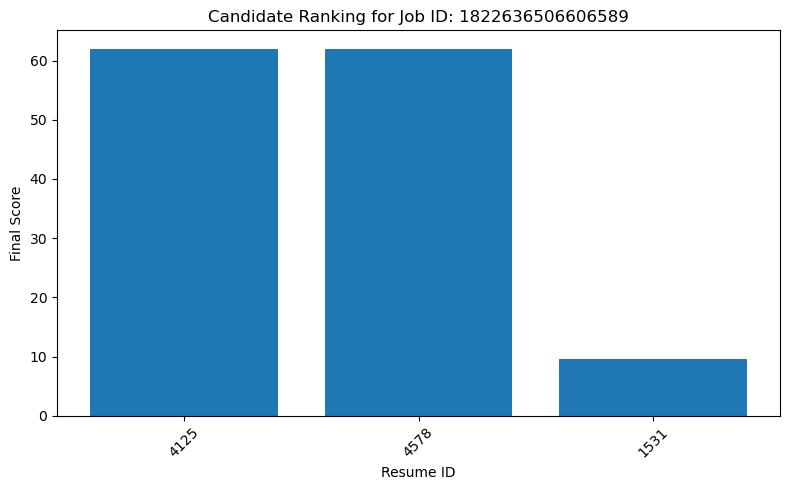

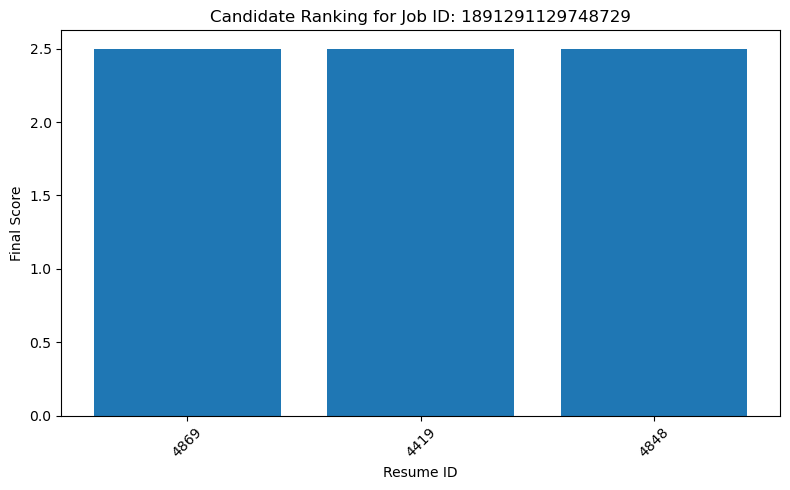

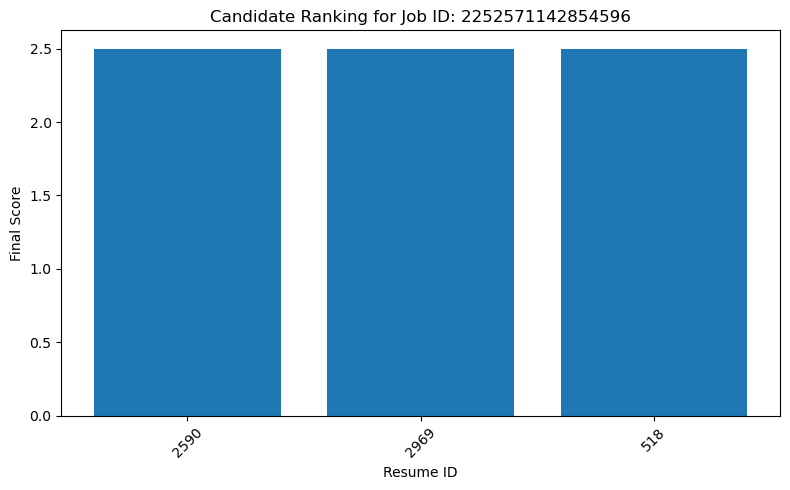

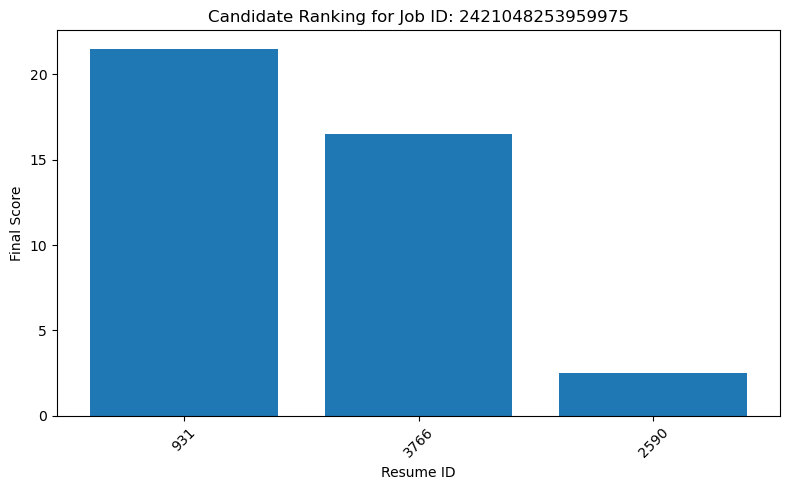

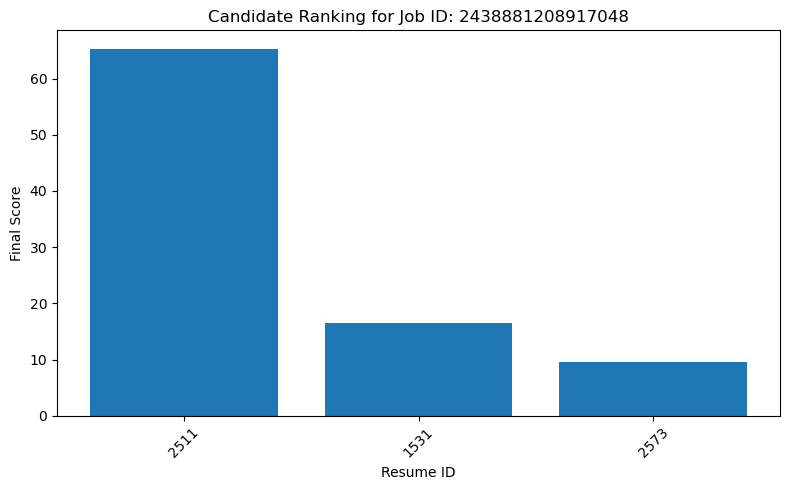

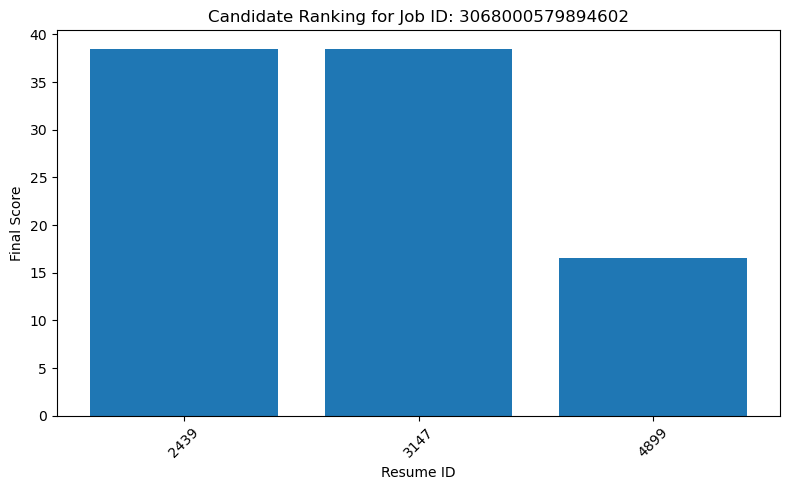

In [204]:
job_ids = results_df["Job ID"].unique()

for job_id in job_ids:

    job_df = (
        results_df[results_df["Job ID"] == job_id]
        .sort_values(by="Final Score", ascending=False)
    )

    plt.figure(figsize=(8, 5))

    plt.bar(
        job_df["Resume ID"].astype(str),
        job_df["Final Score"]
    )

    plt.title(f"Candidate Ranking for Job ID: {job_id}")

    plt.xlabel("Resume ID")
    plt.ylabel("Final Score")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

In [165]:
sample_jds.head()

,Job Id,Job Title,Role,Experience,Qualifications,skills,Responsibilities,Job Description
0,1017340707950150,Procurement Manager,Supplier Diversity Manager,5 to 10 Years,BBA,Supplier diversity programs Diversity and incl...,Promote supplier diversity initiatives and inc...,Promote diversity and inclusion in the supply ...
1,2421048253959975,Architectural Designer,Architectural Drafter,0 to 12 Years,MBA,Architectural drafting AutoCAD 2D and 3D model...,Prepare detailed architectural drawings and pl...,Architectural Drafters assist architects and e...
2,1822636506606589,Art Teacher,Art Education Coordinator,0 to 11 Years,M.Com,Art education curriculum Program development T...,"Coordinate art education programs, curriculum ...",An Art Education Coordinator plans and manages...
3,3068000579894602,Environmental Consultant,Environmental Impact Analyst,5 to 12 Years,B.Com,Environmental impact analysis Data collection ...,Assess the environmental impact of projects an...,Environmental Impact Analysts assess the envir...
4,1747904829392680,Art Teacher,Art Education Coordinator,4 to 13 Years,BCA,Art education curriculum Program development T...,"Coordinate art education programs, curriculum ...",An Art Education Coordinator plans and manages...


In [203]:
sample_jds = sample_jds.reset_index(drop=True)

sample_jds.to_csv("sample_10_jds.csv", index=False)

sample_jds.head()

,Job Id,Job Title,Role,Experience,Qualifications,skills,Responsibilities,Job Description
0,1017340707950150,Procurement Manager,Supplier Diversity Manager,5 to 10 Years,BBA,Supplier diversity programs Diversity and incl...,Promote supplier diversity initiatives and inc...,Promote diversity and inclusion in the supply ...
1,2421048253959975,Architectural Designer,Architectural Drafter,0 to 12 Years,MBA,Architectural drafting AutoCAD 2D and 3D model...,Prepare detailed architectural drawings and pl...,Architectural Drafters assist architects and e...
2,1822636506606589,Art Teacher,Art Education Coordinator,0 to 11 Years,M.Com,Art education curriculum Program development T...,"Coordinate art education programs, curriculum ...",An Art Education Coordinator plans and manages...
3,3068000579894602,Environmental Consultant,Environmental Impact Analyst,5 to 12 Years,B.Com,Environmental impact analysis Data collection ...,Assess the environmental impact of projects an...,Environmental Impact Analysts assess the envir...
4,1747904829392680,Art Teacher,Art Education Coordinator,4 to 13 Years,BCA,Art education curriculum Program development T...,"Coordinate art education programs, curriculum ...",An Art Education Coordinator plans and manages...
